# **Analyzing  Land Cover Changes Using Sentinel-2 and Dynamic World Data**

**Antonio Rangel**  
**Juan Terven**  
**2023**

This notebook focuses on analyzing **population growth trends** and **land cover changes** using data from **Sentinel-2** and **Dynamic World (DW)**. We process and visualize satellite imagery to understand urban expansion and environmental transformations in rapidly growing regions such as **Idaho** and **Utah**.

## **Datasets Used**
### **Dynamic World (DW)**
Dynamic World is a **land cover dataset** developed by **Google** and the **World Resources Institute**. It provides **near real-time, high-resolution land classification maps** using deep learning models applied to **Sentinel-2 imagery**.  
DW includes **nine land cover categories**:  
- Water  
- Trees  
- Grass  
- Crops  
- Shrubland  
- Built-up areas  
- Bare ground  
- Snow/Ice  
- Flooded vegetation  

This dataset enables **detailed environmental monitoring** and **land-use analysis**, supporting applications in **urban planning, deforestation tracking, and climate studies**.

### **Sentinel-2**
Sentinel-2 is a **multispectral satellite mission** from the **European Space Agency (ESA)**, providing **high spatial and temporal resolution imagery**. It is widely used in:  
- **Agriculture**  
- **Forestry**  
- **Land cover classification**  
- **Disaster monitoring**  

The combination of **Sentinel-2's spectral data** with **Dynamic World’s classification models** enhances **Earth observation analysis**, particularly in monitoring **land-use changes and urban expansion**.

## **Workflow Overview**
This notebook follows a structured workflow to extract, process, and analyze satellite imagery for population growth studies.

### **1. Land Cover Pixel Count Analysis**
- Extracts **Dynamic World data** to count pixels per **land cover category**.
- Generates **bar charts** to visualize land cover distribution.
- Allows users to **highlight specific categories** (e.g., urban areas).

### **2. Band Distribution Analysis for Sentinel-2**
- Computes **pixel value distributions** for **Sentinel-2 spectral bands**.
- Generates **histograms** for each band, showing spectral characteristics.
- Users can **choose to save or display** histograms for analysis.

### **3. Clipping and Merging Rasters for Population Growth Studies**
- Identifies **raster images overlapping Idaho and Utah**.
- Merges and **clips raster datasets** using state boundaries.
- Saves **processed raster images** for further study.
- Generates **color-coded visualizations** of the clipped rasters.

### **4. Urban Expansion and Land Cover Change Visualization**
- Creates **bar charts** to analyze urbanization and environmental shifts.
- Allows users to **highlight specific land cover categories**.
- Supports **custom visualization settings** (e.g., colors, category selection).



In [ ]:
import glob
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import os
from rasterio.io import MemoryFile
from tqdm import tqdm
from shapely.geometry import box
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show
import matplotlib.colors as mcolors
import geopandas as gpd

## **Processing and Visualizing Dynamic World Land Cover Data**

In this section, we process raster images from the **Dynamic World (DW)** dataset to count pixels corresponding to different land cover categories and visualize the results. The workflow includes:

### **1. Land Cover Categories**
The **Dynamic World** dataset classifies land cover into the following categories:

| Category ID | Land Cover Type       |
|------------|----------------------|
| **0**      | Water                |
| **1**      | Trees                |
| **2**      | Grass                |
| **3**      | Flooded Vegetation   |
| **4**      | Crops                |
| **5**      | Shrub & Scrub        |
| **6**      | Built Area           |
| **7**      | Bare Ground          |
| **8**      | Snow & Ice           |

### **2. Pixel Counting Process**
The function processes `.tif` raster images to compute the distribution of pixels per land cover category. The steps are:

- **User-defined dataset path**: The user selects the DW dataset folder for the year to analyze.
- **Loading raster images**: All `.tif` files in the selected folder are processed.
- **Reading the first band**: Assumes that the first band represents land cover classifications.
- **Counting pixels by category**: Uses `numpy` to efficiently count occurrences of each land cover type.
- **Progress tracking**: Utilizes `tqdm` for tracking image processing.

### **3. Visualization of Land Cover Distribution**
The processed pixel counts are visualized using `matplotlib`:

- **Bar chart representation**: Each category’s pixel count is displayed.
- **Logarithmic scale**: A log scale is applied to better visualize differences in pixel counts.
- **Rotated labels for readability**: Ensures all category names are visible.
- **Automatic title generation**: Uses the dataset folder name for context.

---

### **How to Run the Analysis**
1. Define the **Dynamic World dataset folder path** for the year to analyze.
    ```python
   dw_folder_path = "path/to/Dynamic_World_Year"
   ```
2. Run the function **analyze_land_cover_pixel_distribution(dw_folder_path)** and the results will be displayed as a bar chart.
    ```python
   pixel_distribution = analyze_land_cover_pixel_distribution(dw_folder_path)
   ```
3. To view the **numerical results in the console**, print the output dictionary.
    ```python
   print("\nPixel count per land cover category:")
for land_cover, count in pixel_distribution.items():
    print(f"{land_cover}: {count}")
   ```


In [4]:
def analyze_land_cover_pixel_distribution(image_folder):
    """
    Analyzes and counts pixels by land cover category in `.tif` images within the specified folder,
    then visualizes the results in a bar chart.

    Parameters:
        image_folder (str): Path to the folder containing `.tif` images.

    Returns:
        dict: A dictionary where keys are land cover category names and values are pixel counts.

    Raises:
        FileNotFoundError: If the specified folder does not exist.
        ValueError: If no `.tif` images are found in the folder.
    """
    # Define Dynamic World land cover categories
    land_cover_categories = [
        "Water", "Trees", "Grass", "Flooded Vegetation", "Crops", 
        "Shrub & Scrub", "Built Area", "Bare Ground", "Snow & Ice"
    ]
    
    num_categories = len(land_cover_categories)
    pixel_count_per_category = np.zeros(num_categories, dtype=int)

    # Verify that the folder exists
    if not os.path.isdir(image_folder):
        raise FileNotFoundError(f"The folder '{image_folder}' does not exist.")

    # Get all `.tif` files in the folder
    tif_files = [filename for filename in os.listdir(image_folder) if filename.endswith('.tif')]
    
    if not tif_files:
        raise ValueError("No `.tif` images found in the specified folder.")

    # Process each `.tif` file in the folder
    for image_filename in tqdm(tif_files, desc="Processing images"):
        image_path = os.path.join(image_folder, image_filename)

        try:
            with rasterio.open(image_path) as raster:
                land_cover_mask = raster.read(1)  # Read the first band (assumed to represent land cover categories)
                for category_index in range(num_categories):
                    pixel_count_per_category[category_index] += np.count_nonzero(land_cover_mask == category_index)
        except Exception as error:
            print(f"Error processing {image_filename}: {error}")

    # Convert results to a dictionary
    pixel_count_dict = {
        land_cover_categories[i]: pixel_count_per_category[i] for i in range(num_categories)
    }

    # Visualization of pixel distribution
    plt.figure(figsize=(10, 5))
    plt.bar(land_cover_categories, pixel_count_per_category, color='skyblue')
    plt.xticks(rotation=90)
    plt.title(f'Pixel Count by Land Cover Category in {os.path.basename(image_folder)}')
    plt.yscale('log')  # Logarithmic scale for better visualization of differences
    plt.xlabel("Land Cover Category")
    plt.ylabel("Pixel Count (log scale)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    return pixel_count_dict


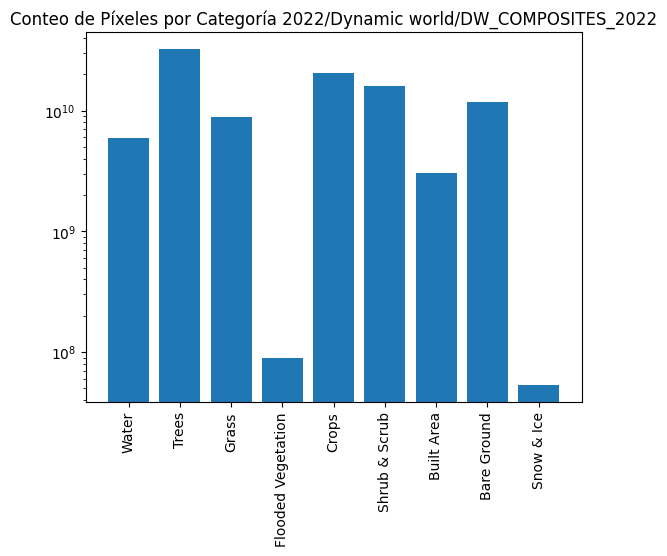

In [17]:
# Define the path to the Dynamic World (DW) dataset for the year to analyze
dw_folder_path = "path/to/Dynamic_World_Year"

# Run the analysis
pixel_distribution = analyze_land_cover_pixel_distribution(dw_folder_path)

# Display results
print("\nPixel count per land cover category:")
for land_cover, count in pixel_distribution.items():
    print(f"{land_cover}: {count}")

## **Band Distribution Analysis**

In this section, we compute and visualize the pixel value distribution for different spectral bands in Sentinel-2 images. The workflow includes:

### **1. Data Collection**
- The user specifies the **input folder** containing `.tif` images.
- All available `.tif` files in the folder are processed.
- Reads pixel values from the available spectral bands.
- Combines pixel data from multiple images into a single dataset for analysis.

### **2. Histogram Visualization**
- Generates histograms for each band to analyze pixel intensity distribution.
- Uses **50 bins** to provide a detailed view of value frequencies.
- Applies a **linear scale** for better data interpretation.
- Includes grid lines for enhanced readability.
- The user can choose to **display the histograms** in the notebook.

### **3. Output Storage (Optional)**
- If enabled, the histograms are **saved as `.png` images**.
- Ensures **high-resolution output** (`dpi=300`).
- Automatically creates the **output folder** if it does not exist.
- The user specifies the **folder where the histograms should be stored**.

---

### **How to Run the Analysis**
1. **Define the required paths** before running the analysis:
   ```python
   data_folder = "path/to/data/folder"  # Folder containing `.tif` images
   output_folder = "path/to/output/folder"  # Folder where histograms will be saved
   ```
2. **Run the function with the desired settings**:
   ```python
   plot_band_distribution(data_folder, output_folder, save_histogram=True, show_histogram=False)
   ```
3. **Modify the behavior as needed**:
    * To only display histograms (without saving them)
    
   ```python
   plot_band_distribution(data_folder, output_folder, save_histogram=False, show_histogram=True)
   ```
   * To both save and display histograms
   
   ```python
   plot_band_distribution(data_folder, output_folder, save_histogram=True, show_histogram=True)
    ```

In [29]:
def plot_band_distribution(input_folder, dataset_name="Sentinel-2 RGB", num_bands=3, save_histogram=True, show_histogram=False, output_folder=None):
    """
    Processes all `.tif` images in the specified folder, extracts pixel values for each band,
    and creates histograms for the combined pixel distributions.

    Parameters:
        input_folder (str): Path to the folder containing `.tif` images.
        dataset_name (str): Title for the figures.
        num_bands (int): Number of bands to process.
        save_histogram (bool): If True, saves histograms as `.png` images.
        show_histogram (bool): If True, displays histograms in Jupyter Notebook.
        output_folder (str, optional): Path to save the histogram images (required if save_histogram=True).

    Returns:
        None. Displays or saves histograms based on user selection.
    """
    # Validate output folder if saving histograms
    if save_histogram and output_folder is None:
        raise ValueError("You must specify an output folder if save_histogram is enabled.")
    if save_histogram and output_folder:
        os.makedirs(output_folder, exist_ok=True)

    # Collect all `.tif` files in the folder
    file_paths = glob.glob(os.path.join(input_folder, '*.tif'))
    
    if not file_paths:
        raise ValueError(f"No `.tif` images found in the folder: {input_folder}")

    # Process each band
    for band_index in range(1, num_bands + 1):
        combined_band_data = []

        # Read pixel values from all images
        for file_path in tqdm(file_paths, desc=f"Processing Band {band_index}"):
            try:
                with rasterio.open(file_path) as src:
                    # Ensure the band index is valid
                    if band_index > src.count:
                        print(f"Skipping {file_path}: Band {band_index} does not exist in this image.")
                        continue
                    band_data = src.read(band_index).flatten()
                    combined_band_data.extend(band_data)
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

        # Convert to NumPy array for better performance
        combined_band_data = np.array(combined_band_data)

        # Plot histogram
        plt.figure(figsize=(10, 6))
        plt.hist(combined_band_data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        plt.title(f'Pixel Value Distribution for Band {band_index} ({dataset_name})', fontsize=14)
        plt.xlabel('Pixel Value', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.yscale('linear')

        # Save the histogram if the user wants to
        if save_histogram:
            output_path = os.path.join(output_folder, f'histogram_band_{band_index}.png')
            plt.savefig(output_path, dpi=300, bbox_inches='tight')
            print(f"Histogram saved: {output_path}")

        # Show the histogram in Jupyter Notebook if requested
        if show_histogram:
            plt.show()
        else:
            plt.close()  # Free memory if not displaying

In [30]:
# Define the paths
data_folder = "path/to/data/folder"  # User-defined: folder containing `.tif` images
output_folder = "path/to/output/folder"  # User-defined: folder to save histograms

# Run the function: choose whether to save or display histograms
plot_band_distribution(data_folder, dataset_name="Sentinel-2 RGB", num_bands=3, save_histogram=True, show_histogram=False, output_folder=output_folder)


100%|██████████| 5/5 [00:23<00:00,  4.60s/it]


## **Analyzing Cities with the Highest Population Growth in the Last 10 Years**

This section focuses on identifying and visualizing areas with the highest population growth in **Idaho** and **Utah** using raster data. The workflow includes:

### **1. Data Collection**
- The user specifies the **input folder** containing `.tif` raster images.
- The function identifies **overlapping rasters** based on the state's polygon boundaries.
- Rasters are **merged and clipped** to match the region of interest.

### **2. Raster Clipping and Processing**
- Merges all rasters covering the specified area.
- Clips the merged raster using the **Idaho or Utah polygon**.
- Assigns **NaN values** to non-relevant areas to remove background noise.
- Saves the **clipped raster** as a `.tif` file for further analysis.

### **3. Visualization and Analysis**
- Generates a **color-coded visualization** of the clipped raster.
- The user can choose to **save or display** the visualization.
- The output includes a **pixel count per category**, useful for analyzing land use changes.

### **4. Output Storage**
- The clipped raster and visualization are **saved in the user-defined output folder**.
- Ensures **high-resolution output** (`dpi=300`).
- Automatically creates the **output folder** if it does not exist.

---

### **How to Run the Analysis**
1. **Define the input and output folders**:
   ```python
   data_folder = "path/to/raster/folder"  # Folder containing `.tif` images
   output_folder = "path/to/output/folder"  # Folder where results will be saved
2. **Run the function with the desired settings**:
   ```python
   category_counts = clip_and_save_raster(gdf_idaho, data_folder, output_folder, color_mapping, state="Idaho", year="2022")
   ```
3. **View pixel counts**:
    
   ```python
   if category_counts is not None:
    print("Pixel count per category:", category_counts)

   ```
---
### Data source
U.S Census Bureau  
https://www.census.gov/library/visualizations/interactive/historical-apportionment-data-map.html

In [3]:
# Load Idaho polygon
gdf_idaho = gpd.read_file("idaho_polygon.shp")

#Load Utah polygon
gdf_utah =  gpd.read_file('Utah_polygon.shp')

In [5]:
#Define a color_mapping for dynamic world
color_mapping = {
    0: '#ffffff',    #'#419bdf',   # Clase 0: Agua
    1: '#ffffff',    # '#397d49',  # Clase 1: Árboles
    2: '#ffffff',    #'#88b053',   # Clase 2: Pasto
    3: '#ffffff',    #'#7a87c6',   # Clase 3: Vegetación inundada
    4: '#ffffff',    #'#e49635',   # Clase 4: Cultivos
    5: '#ffffff',    #'#dfc35a',   # Clase 5: Arbustos y matorrales
    6: '#c4281b',                  # Clase 6: Áreas construidas
    7: '#ffffff',    #'#a59b8f',   # Clase 7: Áreas sin vegetación
    8: '#ffffff',    #'#b39fe1'    # Clase 8: Nieve y hielo
}

In [2]:
def clip_and_save_raster(gdf, raster_folder, output_folder, color_mapping, state, year, num_categories=9, save_visualization=True):
    """
    Clips raster files overlapping with a specified polygon, merges them, and saves the result.
    Optionally visualizes and saves the clipped raster.

    Parameters:
        gdf (GeoDataFrame): GeoDataFrame containing the polygon geometry.
        raster_folder (str): Folder containing the raster files.
        output_folder (str): Folder where the clipped raster and visualizations will be saved.
        color_mapping (dict): Dictionary mapping raster values to colors.
        state (str): State name for visualization title.
        year (str): Year for visualization title.
        num_categories (int): Number of land cover categories.
        save_visualization (bool): Whether to save the raster visualization.

    Returns:
        np.ndarray: Array containing pixel counts for each land cover category.
    """
    
    # Ensure output directory exists
    os.makedirs(output_folder, exist_ok=True)

    # Convert polygon geometry for raster processing
    target_geom = [gdf.geometry.iloc[0]]

    # Find overlapping rasters
    overlapping_rasters = []
    for filename in tqdm(os.listdir(raster_folder), desc="Checking overlapping rasters"):
        if filename.endswith('.tif'):
            raster_path = os.path.join(raster_folder, filename)
            with rasterio.open(raster_path) as src:
                raster_bounds = box(*src.bounds)
                raster_geom = gpd.GeoDataFrame({'geometry': [raster_bounds]}, crs=src.crs)
                
                if raster_geom.crs != gdf.crs:
                    raster_geom = raster_geom.to_crs(gdf.crs)
                
                if raster_geom.intersects(gdf.unary_union).iloc[0]:
                    overlapping_rasters.append(raster_path)

    if not overlapping_rasters:
        print("No overlapping rasters found.")
        return None
    
    print(f"Found {len(overlapping_rasters)} overlapping rasters.")

    # Merge overlapping rasters
    raster_list = [rasterio.open(fp) for fp in overlapping_rasters]
    merged_raster, merged_transform = merge(raster_list)

    # Define output raster profile
    profile = raster_list[0].profile
    profile.update({
        "driver": "GTiff",
        "height": merged_raster.shape[1],
        "width": merged_raster.shape[2],
        "transform": merged_transform,
        "count": merged_raster.shape[0],
        "nodata": 255  # Define no-data value
    })

    # Clip raster using target polygon
    with MemoryFile() as memfile:
        with memfile.open(**profile) as dataset:
            dataset.write(merged_raster)
            clipped_raster, clipped_transform = mask(dataset=dataset, shapes=target_geom, crop=True)

            # Update profile for the clipped raster
            profile.update({
                "height": clipped_raster.shape[1],
                "width": clipped_raster.shape[2],
                "transform": clipped_transform
            })

            # Save clipped raster
            clipped_raster_path = os.path.join(output_folder, f"{state}_{year}_clipped.tif")
            with rasterio.open(clipped_raster_path, "w", **profile) as dst:
                dst.write(clipped_raster)

    print(f"Clipped raster saved at: {clipped_raster_path}")

    # Visualization setup
    if save_visualization:
        color_mapping[255] = '#ffffff'  # No-data values in white
        cmap = mcolors.ListedColormap([color_mapping[i] for i in sorted(color_mapping.keys())])
        bounds = sorted(set(color_mapping.keys())) + [max(color_mapping.keys()) + 1]
        norm = mcolors.BoundaryNorm(bounds, cmap.N)

        # Plot the clipped raster
        fig, ax = plt.subplots(figsize=(10, 10))
        show(clipped_raster, transform=clipped_transform, ax=ax, cmap=cmap, norm=norm)
        gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

        plt.title(f'{state} {year}')
        ax.axis('off')

        visualization_path = os.path.join(output_folder, f"{state}_{year}_clipped_visualization.png")
        plt.savefig(visualization_path, bbox_inches='tight', pad_inches=0)
        plt.show()

        print(f"Visualization saved at: {visualization_path}")

    # Count pixels per category
    category_counts = np.zeros(num_categories, dtype=int)
    for category in range(num_categories):
        category_counts[category] += np.count_nonzero(clipped_raster == category)

    # Close all raster files
    for src in raster_list:
        src.close()

    return category_counts

Verificando rasters coincidentes:   0%|          | 0/797 [00:00<?, ?it/s]/tmp/ipykernel_2252118/2674840068.py:43: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  if raster_geom.intersects(gdf_idaho.unary_union).iloc[0]:
Verificando rasters coincidentes: 100%|██████████| 797/797 [00:02<00:00, 291.21it/s]


Rásteres coincidentes con el area del shapefile: 41


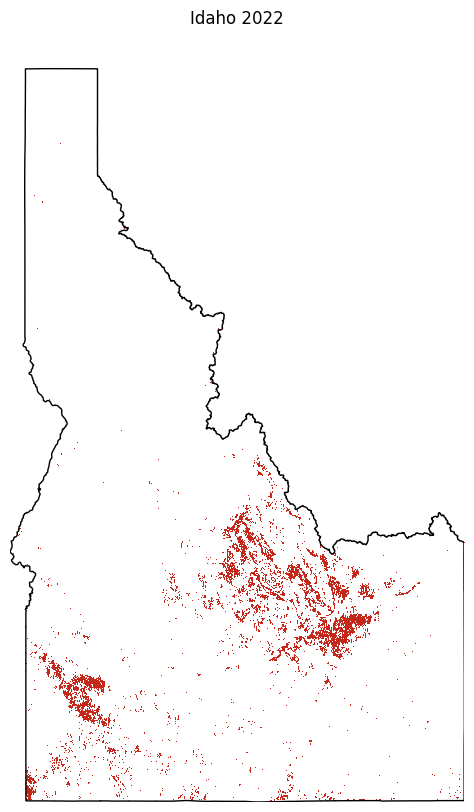

Ráster recortado guardado en Idaho/
Visualización guardada en Idaho/


In [7]:
# Define paths for input data and output results
data_folder = "path/to/raster/folder"  # User-defined folder with raster images
output_folder = "path/to/output/folder"  # User-defined output folder

# Run the function
category_counts = clip_and_save_raster(
    gdf=gdf_idaho,
    raster_folder=data_folder,
    output_folder=output_folder,
    color_mapping={0: "#0000FF", 1: "#008000", 2: "#00FF00"},  # Example color mapping
    state="Idaho",
    year="2022",
    num_categories=9,
    save_visualization=True
)

# Print pixel counts per category
if category_counts is not None:
    print("Pixel count per category:", category_counts)


In [ ]:
def plot_highlighted_bar_chart(pixel_counts, state, highlighted_category="Built Area", highlight_color="red", default_color="blue"):
    """
    Plots a bar chart of pixel counts per category, highlighting a specific category.

    Parameters:
        pixel_counts (list or np.ndarray): Corresponding pixel counts per category.
        state (str): Name of the state for the plot title.
        highlighted_category (str, optional): Category to highlight. Defaults to "Built Area".
        highlight_color (str, optional): Color for the highlighted category. Defaults to "red".
        default_color (str, optional): Color for the other categories. Defaults to "blue".

    Returns:
        None. Displays the bar chart.
    """
    # Define Dynamic World land cover categories
    land_cover_categories = [
        "Water", "Trees", "Grass", "Flooded Vegetation", "Crops", 
        "Shrub & Scrub", "Built Area", "Bare Ground", "Snow & Ice"
    ]
    # Validate input length
    if len(land_cover_categories) != len(pixel_counts):
        raise ValueError("The length of land_cover_categories and pixel_counts must be the same.")

    # Define colors, highlighting the selected category
    colors = [highlight_color if category == highlighted_category else default_color for category in land_cover_categories]

    # Create the bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(land_cover_categories, pixel_counts, color=colors)
    plt.xticks(rotation=90)
    plt.title(f'Pixel Count per Category in {state}')
    plt.yscale('log')
    plt.xlabel("Land Cover Category")
    plt.ylabel("Pixel Count (log scale)")
    
    # Highlight the value of the selected category
    for i, category in enumerate(land_cover_categories):
        if category == highlighted_category:
            plt.text(i, pixel_counts[i], str(pixel_counts[i]), ha='center', va='bottom', color='black', fontweight='bold')

    plt.show()

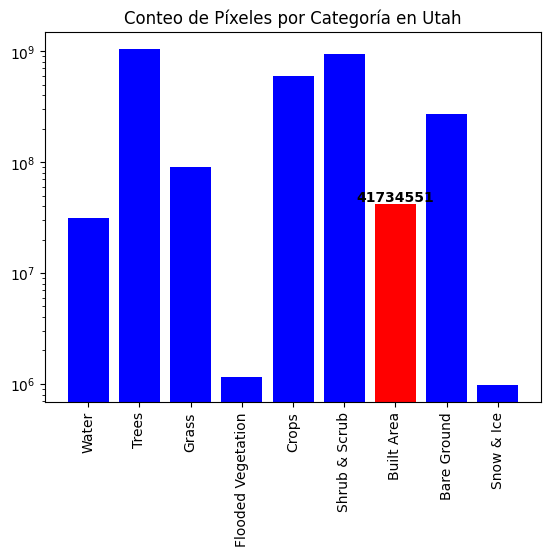

In [8]:
# Example usage
state = "Idaho"
highlighted_category = "Built Area"
plot_highlighted_bar_chart(category_counts, state, highlighted_category)

Verificando rasters coincidentes:   0%|          | 0/797 [00:00<?, ?it/s]/tmp/ipykernel_2252118/2674840068.py:43: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  if raster_geom.intersects(gdf_idaho.unary_union).iloc[0]:
Verificando rasters coincidentes: 100%|██████████| 797/797 [00:02<00:00, 285.20it/s]


Rásteres coincidentes con el area del shapefile: 37


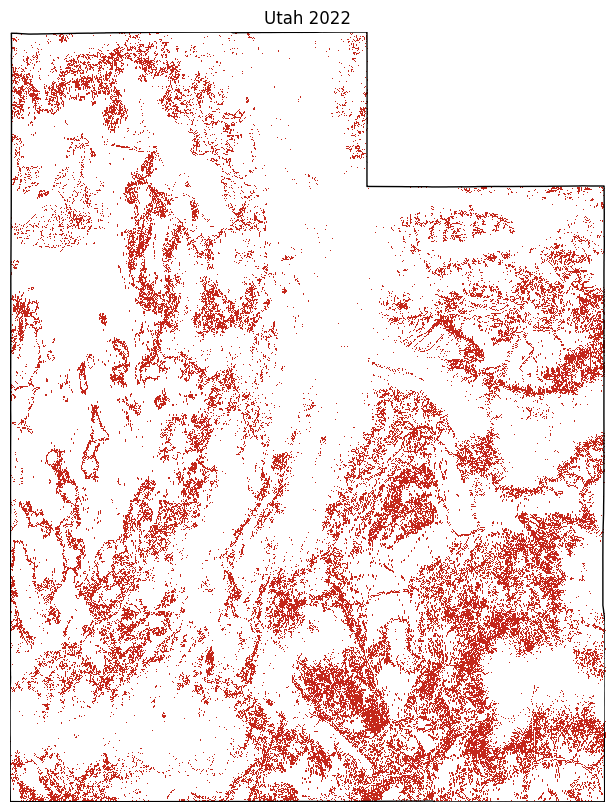

Ráster recortado guardado en Utah/
Visualización guardada en Utah/


In [9]:
# Define paths for input data and output results
data_folder = "path/to/raster/folder"  # User-defined folder with raster images
output_folder = "path/to/output/folder"  # User-defined output folder

# Run the function
category_counts = clip_and_save_raster(
    gdf=gdf_idaho,
    raster_folder=data_folder,
    output_folder=output_folder,
    color_mapping={0: "#0000FF", 1: "#008000", 2: "#00FF00"},  # Example color mapping
    state="Idaho",
    year="2022",
    num_categories=9,
    save_visualization=True
)

# Print pixel counts per category
if category_counts is not None:
    print("Pixel count per category:", category_counts)


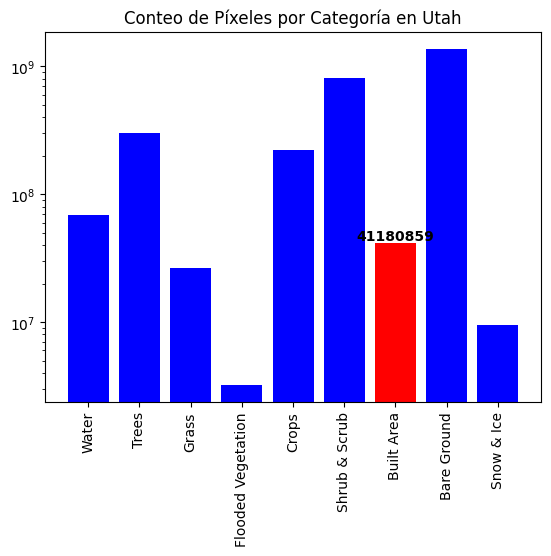

In [10]:
state = "Utah"
highlighted_category = "Built Area"
plot_highlighted_bar_chart(category_counts, state, highlighted_category)